In [ ]:
# 1. CÀI ĐẶT THƯ VIỆN
import subprocess
import sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "roboflow", "pandas", "numpy", "matplotlib", "seaborn", "Pillow", "PyYAML", "tqdm"
])
print("Cài đặt hoàn tất. Chuyển sang cell tiếp theo.")

Cài đặt hoàn tất. Chuyển sang cell tiếp theo.


In [ ]:
# 2. CẤU HÌNH VÀ GIỚI THIỆU DỮ LIỆU
import os
import re
import json
import math
import hashlib
import random
import shutil
from collections import defaultdict
from datetime import datetime, timezone
from getpass import getpass
from pathlib import Path
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import yaml
from PIL import Image, ImageOps
from tqdm.auto import tqdm
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (12, 6), "figure.dpi": 110})
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 90)

WORKSPACE_ID = "material-identification"
PROJECT_ID = "garbage-classification-3"
VERSION_NUMBER = 2
SOURCE_URL = f"https://universe.roboflow.com/{WORKSPACE_ID}/{PROJECT_ID}/dataset/{VERSION_NUMBER}"

EXISTING_DATASET_DIR = ""
DOWNLOAD_DIR = Path("/content/GARBAGE-CLASSIFICATION-3-2")
OUTPUT_BASE = Path("/content/garbage_eda_outputs")
CHECK_BYTE_DUPLICATES = True
BOUNDARY_TOLERANCE = 1e-6
SPLITS = ["train", "valid", "test"]
SPLIT_COLORS = {"train": "#2878b5", "valid": "#f2994a", "test": "#38a88c"}
AUTO_DOWNLOAD_RESULTS = False

print("TỔNG QUAN DỮ LIỆU RÁC — OBJECT DETECTION")
print("Nguồn dữ liệu:", SOURCE_URL)
print("Mỗi dòng YOLO: class_id x_center y_center width height; tọa độ được chuẩn hóa.")
print("Nội dung: giới thiệu → quy mô/split → EDA → điểm mạnh/yếu → hướng khắc phục.")
print("Mọi số liệu được tính từ bản dữ liệu đang đọc; không điền sẵn số liệu của báo cáo.")
print("Các hướng khắc phục chỉ là đề xuất. Không tạo dataset đã làm sạch.")
print("Phiên bản thư viện:", {p: package_version(p) for p in
      ["numpy", "pandas", "matplotlib", "seaborn", "Pillow", "PyYAML"]})

TỔNG QUAN DỮ LIỆU RÁC — OBJECT DETECTION
Nguồn dữ liệu: https://universe.roboflow.com/material-identification/garbage-classification-3/dataset/2
Mỗi dòng YOLO: class_id x_center y_center width height; tọa độ được chuẩn hóa.
Nội dung: giới thiệu → quy mô/split → EDA → điểm mạnh/yếu → hướng khắc phục.
Mọi số liệu được tính từ bản dữ liệu đang đọc; không điền sẵn số liệu của báo cáo.
Các hướng khắc phục chỉ là đề xuất. Không tạo dataset đã làm sạch.
Phiên bản thư viện: {'numpy': '2.1.3', 'pandas': '2.2.3', 'matplotlib': '3.10.0', 'seaborn': '0.13.2', 'Pillow': '11.3.0', 'PyYAML': '6.0.3'}


In [ ]:
# 3. TẢI DỮ LIỆU TỪ ROBOFLOW
def obtain_roboflow_key():
    key = os.environ.get("ROBOFLOW_API_KEY", "").strip()
    if not key:
        try:
            from google.colab import userdata
            key = userdata.get("ROBOFLOW_API_KEY").strip()
        except Exception:
            key = ""
    if not key:
        key = getpass("Nhập Roboflow API key của bạn (không hiển thị): ").strip()
    if not key:
        raise ValueError("Chưa có API key. Thêm Colab Secret rồi chạy lại cell này.")
    return key


def download_from_roboflow():
    from roboflow import Roboflow
    api_key = obtain_roboflow_key()
    try:
        rf = Roboflow(api_key=api_key)
        project = rf.workspace(WORKSPACE_ID).project(PROJECT_ID)
        dataset = project.version(VERSION_NUMBER).download("yolov8", location=str(DOWNLOAD_DIR))
        return Path(dataset.location).resolve()
    except Exception:
        raise RuntimeError(
            "Chưa tải được dữ liệu. Kiểm tra mạng, API key và quyền tải phiên bản 2 "
            "trên Roboflow. Hoặc tải YOLOv8 thủ công từ Roboflow rồi đặt EXISTING_DATASET_DIR."
        ) from None
    finally:
        del api_key


if EXISTING_DATASET_DIR:
    DATASET_DIR = Path(EXISTING_DATASET_DIR).expanduser().resolve()
    if not (DATASET_DIR / "data.yaml").is_file():
        raise FileNotFoundError(f"Không tìm thấy data.yaml tại {DATASET_DIR}")
    print("Đọc bản dữ liệu Roboflow đã có. Bạn cần bảo đảm đúng dự án/phiên bản.")
elif (DOWNLOAD_DIR / "data.yaml").is_file():
    DATASET_DIR = DOWNLOAD_DIR.resolve()
    print("Dùng lại dữ liệu đã tải trong phiên Colab hiện tại.")
elif DOWNLOAD_DIR.exists() and any(DOWNLOAD_DIR.iterdir()):
    raise RuntimeError(
        "Thư mục tải có dữ liệu nhưng thiếu data.yaml. Kiểm tra lần tải trước "
        "hoặc đổi DOWNLOAD_DIR sang một thư mục mới; notebook không tự xóa dữ liệu."
    )
else:
    DATASET_DIR = download_from_roboflow()

print("Thư mục dữ liệu:", DATASET_DIR)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/GARBAGE-CLASSIFICATION-3-2 in yolov8:: 100%|██████████| 20940/20940 [00:03<00:00, 5255.88it/s]


Thư mục dữ liệu: /content/GARBAGE-CLASSIFICATION-3-2


In [ ]:
# 4. ĐỌC SCHEMA VÀ XÁC ĐỊNH CÁC SPLIT — KHÔNG GIẢ ĐỊNH ẢNH LUÔN LÀ 640×640
yaml_path = DATASET_DIR / "data.yaml"
with yaml_path.open("r", encoding="utf-8-sig") as stream:
    data_config = yaml.safe_load(stream)
if not isinstance(data_config, dict):
    raise ValueError("data.yaml phải là một mapping.")

raw_names = data_config.get("names")
if isinstance(raw_names, list):
    class_names = [str(name) for name in raw_names]
elif isinstance(raw_names, dict):
    names_by_id = {int(key): str(value) for key, value in raw_names.items()}
    if set(names_by_id) != set(range(len(names_by_id))):
        raise ValueError("Class ID trong names phải liên tiếp từ 0.")
    class_names = [names_by_id[i] for i in range(len(names_by_id))]
else:
    raise ValueError("data.yaml thiếu danh sách names hợp lệ.")
if not class_names or len(set(class_names)) != len(class_names):
    raise ValueError("Schema rỗng hoặc có tên lớp trùng nhau; cần kiểm tra thủ công.")
NC = len(class_names)
SCHEMA_NC_MATCH = int(data_config.get("nc", NC)) == NC
if not SCHEMA_NC_MATCH:
    print("CẢNH BÁO: nc khác độ dài names. Sử dụng mapping names cho EDA, không sửa data.yaml.")

metadata_rf = data_config.get("roboflow", {}) or {}
for field, expected in [("workspace", WORKSPACE_ID), ("project", PROJECT_ID), ("version", VERSION_NUMBER)]:
    actual = metadata_rf.get(field)
    if actual is not None and str(actual) != str(expected):
        raise ValueError(f"Metadata {field}={actual} không khớp cấu hình {expected}.")
print("Thông tin Roboflow trong export:",
      {k: metadata_rf.get(k, "không có") for k in ["workspace", "project", "version", "license"]})
display(pd.DataFrame({"class_id": range(NC), "class_name": class_names}))
print("Số lớp được đọc từ data.yaml:", NC, "— không thêm lớp chỉ vì xuất hiện trên giao diện dự án.")


def resolve_split_dirs(root, config):
    """Hỗ trợ cấu trúc YOLOv8 Roboflow: split/images và split/labels."""
    found = {}
    for split in SPLITS:
        aliases = ["valid", "val", "validation"] if split == "valid" else [split]
        candidates = [root / alias / "images" for alias in aliases]
        yaml_key = "val" if split == "valid" else split
        configured = config.get(yaml_key)
        if isinstance(configured, str):
            p = Path(configured)
            bases = [root]
            if config.get("path"):
                base = Path(config["path"])
                bases.insert(0, base if base.is_absolute() else root / base)
            candidates += [p] if p.is_absolute() else [base / p for base in bases]
        image_dir = next((p.resolve() for p in candidates if p.is_dir()), None)
        if image_dir is None:
            raise FileNotFoundError(f"Thiếu thư mục ảnh của split {split}. Kiểm tra cấu trúc export.")
        if image_dir.name != "images":
            raise ValueError("Notebook yêu cầu cấu trúc split/images, split/labels của YOLOv8 Roboflow.")
        label_dir = image_dir.parent / "labels"
        if not label_dir.is_dir():
            print(f"CẢNH BÁO: {split} thiếu thư mục labels; vẫn thống kê ảnh và ghi nhận thiếu nhãn.")
        found[split] = {"images": image_dir, "labels": label_dir}
    if len({str(x["images"]) for x in found.values()}) != len(SPLITS):
        raise ValueError("Hai split trỏ tới cùng một thư mục ảnh. Không tiếp tục để tránh đếm trùng.")
    return found


split_dirs = resolve_split_dirs(DATASET_DIR, data_config)
display(pd.DataFrame([{ "split": s, **{k: str(v) for k, v in d.items()}}
                      for s, d in split_dirs.items()]))

if OUTPUT_BASE.resolve() == DATASET_DIR or DATASET_DIR in OUTPUT_BASE.resolve().parents:
    raise ValueError("OUTPUT_BASE phải nằm ngoài thư mục dataset.")
OUTPUT_DIR = OUTPUT_BASE / datetime.now(timezone.utc).strftime("run_%Y%m%d_%H%M%S_%f")
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir()


def finish_figure(fig, filename):
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Kết quả EDA sẽ được lưu tại:", OUTPUT_DIR)

Thông tin Roboflow trong export: {'workspace': 'material-identification', 'project': 'garbage-classification-3', 'version': 2, 'license': 'CC BY 4.0'}


,class_id,class_name
0,0,BIODEGRADABLE
1,1,CARDBOARD
2,2,GLASS
3,3,METAL
4,4,PAPER
5,5,PLASTIC


Số lớp được đọc từ data.yaml: 6 — không thêm lớp chỉ vì xuất hiện trên giao diện dự án.


,split,images,labels
0,train,/content/GARBAGE-CLASSIFICATION-3-2/train/images,/content/GARBAGE-CLASSIFICATION-3-2/train/labels
1,valid,/content/GARBAGE-CLASSIFICATION-3-2/valid/images,/content/GARBAGE-CLASSIFICATION-3-2/valid/labels
2,test,/content/GARBAGE-CLASSIFICATION-3-2/test/images,/content/GARBAGE-CLASSIFICATION-3-2/test/labels


Kết quả EDA sẽ được lưu tại: /content/garbage_eda_outputs/run_20260902_173922_351271


In [ ]:
# 5. HÀM ĐỌC ẢNH/NHÃN VÀ KIỂM TRA CHẤT LƯỢNG

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
BOX_COLUMNS = ["annotation_id", "split", "image_key", "file_name", "label_path", "line_no",
               "has_image", "class_id", "class_name", "class_valid", "x_center", "y_center",
               "bbox_w", "bbox_h", "bbox_area", "aspect_ratio", "img_w", "img_h",
               "finite_geometry", "geometry_valid", "annotation_valid", "invalid_reasons",
               "zero_width", "zero_height", "out_of_bounds"]
ISSUE_COLUMNS = ["split", "file_name", "label_path", "line_no", "issue", "detail"]
IMAGE_COLUMNS = ["split", "image_key", "file_name", "image_path", "pair_key", "original_id",
                 "filename_prefix", "image_readable", "img_w", "img_h", "file_bytes", "sha256",
                 "label_exists", "pair_ambiguous"]
LABEL_COLUMNS = ["split", "label_path", "pair_key", "n_nonblank_lines", "n_numeric_rows", "n_images"]


def original_id(filename):
    return re.sub(r"\.rf\.[^.]+$", "", Path(filename).stem, flags=re.IGNORECASE).casefold()


def filename_prefix(filename):
    match = re.match(r"([A-Za-z]+)", Path(filename).name)
    return match.group(1).lower() if match else "unknown"


def byte_hash(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def audit_yolo_dataset(directories, names, check_hash=True, tolerance=1e-6):
    images, boxes, labels, issues = [], [], [], []

    def issue(split, filename, label_path, line_no, kind, detail):
        issues.append(dict(zip(ISSUE_COLUMNS,
                               [split, filename, str(label_path), line_no, kind, str(detail)])))

    for split, folders in directories.items():
        image_root, label_root = folders["images"], folders["labels"]
        image_paths = sorted(p for p in image_root.rglob("*")
                             if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
        label_paths = sorted(p for p in label_root.rglob("*")
                             if p.is_file() and p.suffix.lower() == ".txt")
        image_by_pair, label_by_pair = defaultdict(list), defaultdict(list)
        for path in label_paths:
            label_by_pair[path.relative_to(label_root).with_suffix("").as_posix()].append(path)

        for path in tqdm(image_paths, desc=f"Đọc ảnh {split}"):
            relative = path.relative_to(image_root)
            pair = relative.with_suffix("").as_posix()
            readable, width, height, digest = True, np.nan, np.nan, None
            try:
                with Image.open(path) as img:
                    img.load()
                    width, height = img.size
            except Exception as exc:
                readable = False
                issue(split, relative.as_posix(), "", 0, "unreadable_image", type(exc).__name__)
            if check_hash:
                try:
                    digest = byte_hash(path)
                except OSError as exc:
                    issue(split, relative.as_posix(), "", 0, "hash_read_error", type(exc).__name__)
            record = dict(zip(IMAGE_COLUMNS, [
                split, f"{split}/{relative.as_posix()}", relative.as_posix(), str(path), pair,
                original_id(path.name), filename_prefix(path.name), readable, width, height,
                path.stat().st_size, digest, bool(label_by_pair.get(pair)), False
            ]))
            images.append(record)
            image_by_pair[pair].append(record)

        for pair, records in image_by_pair.items():
            ambiguous = len(records) > 1 or len(label_by_pair.get(pair, [])) > 1
            for record in records:
                record["pair_ambiguous"] = ambiguous
                if ambiguous:
                    issue(split, record["file_name"], "", 0, "ambiguous_image_label_pair",
                          "Nhiều ảnh/nhãn dùng cùng stem; không tự chọn một ảnh để ghép nhãn.")
                if not record["label_exists"]:
                    issue(split, record["file_name"], "", 0, "missing_label_file",
                          "Thiếu tệp nhãn; không tự kết luận đây là ảnh background hợp lệ.")

        for label_path in tqdm(label_paths, desc=f"Đọc nhãn {split}"):
            pair = label_path.relative_to(label_root).with_suffix("").as_posix()
            matches = image_by_pair.get(pair, [])
            matched = len(matches) == 1 and len(label_by_pair[pair]) == 1
            record = matches[0] if matched else None
            fname = record["file_name"] if record else pair
            image_key = record["image_key"] if record else f"{split}/[unpaired]/{pair}"
            if not matches:
                issue(split, fname, label_path, 0, "orphan_label_file", "Có nhãn nhưng không có ảnh tương ứng.")
            try:
                lines = label_path.read_text(encoding="utf-8-sig").splitlines()
            except (OSError, UnicodeError) as exc:
                issue(split, fname, label_path, 0, "unreadable_label_file", type(exc).__name__)
                labels.append(dict(zip(LABEL_COLUMNS,
                                       [split, str(label_path), pair, None, 0, len(matches)])))
                continue
            nonblank = sum(bool(line.strip()) for line in lines)
            numeric = 0
            if nonblank == 0:
                issue(split, fname, label_path, 0, "empty_label_file",
                      "Có thể là ảnh background; cần xem ảnh, không tự coi là nhãn sai.")
            for line_no, line in enumerate(lines, 1):
                if not line.strip():
                    continue
                tokens = line.split()
                if len(tokens) != 5:
                    issue(split, fname, label_path, line_no, "wrong_column_count",
                          f"Cần 5 cột YOLO detection, nhận {len(tokens)} cột.")
                    continue
                try:
                    cid, xc, yc, bw, bh = map(float, tokens)
                except ValueError:
                    issue(split, fname, label_path, line_no, "non_numeric_value", line[:160])
                    continue
                numeric += 1
                class_valid = math.isfinite(cid) and cid.is_integer() and 0 <= cid < len(names)
                class_name = names[int(cid)] if class_valid else "[INVALID_CLASS]"
                finite = all(math.isfinite(v) for v in [xc, yc, bw, bh])
                outside = finite and (
                    min(xc - bw / 2, yc - bh / 2) < -tolerance or
                    max(xc + bw / 2, yc + bh / 2) > 1 + tolerance or
                    min(xc, yc) < -tolerance or max(xc, yc) > 1 + tolerance
                )
                reasons = []
                if not class_valid:
                    reasons.append("invalid_class_id")
                if not finite:
                    reasons.append("non_finite_geometry")
                else:
                    if bw <= 0:
                        reasons.append("non_positive_width")
                    if bh <= 0:
                        reasons.append("non_positive_height")
                    if outside:
                        reasons.append("out_of_bounds")
                geometry_valid = finite and bw > 0 and bh > 0 and not outside
                ratio = bw / bh if geometry_valid else np.nan
                area = bw * bh if finite else np.nan
                boxes.append(dict(zip(BOX_COLUMNS, [
                    f"{split}/{label_path.relative_to(label_root).as_posix()}:{line_no}",
                    split, image_key, fname, str(label_path), line_no, matched,
                    cid, class_name, class_valid, xc, yc, bw, bh, area, ratio,
                    record["img_w"] if record else np.nan, record["img_h"] if record else np.nan,
                    finite, geometry_valid, geometry_valid and class_valid,
                    ";".join(reasons), bw == 0, bh == 0, outside
                ])))
                for reason in reasons:
                    issue(split, fname, label_path, line_no, reason, line[:160])
            labels.append(dict(zip(LABEL_COLUMNS,
                                   [split, str(label_path), pair, nonblank, numeric, len(matches)])))

    image_df = pd.DataFrame(images, columns=IMAGE_COLUMNS)
    box_df = pd.DataFrame(boxes, columns=BOX_COLUMNS)
    label_df = pd.DataFrame(labels, columns=LABEL_COLUMNS)
    issues_df = pd.DataFrame(issues, columns=ISSUE_COLUMNS)
    for name in ["has_image", "class_valid", "finite_geometry", "geometry_valid",
                 "annotation_valid", "zero_width", "zero_height", "out_of_bounds"]:
        box_df[name] = box_df[name].astype(bool)
    for name in ["class_id", "x_center", "y_center", "bbox_w", "bbox_h", "bbox_area",
                 "aspect_ratio", "img_w", "img_h"]:
        box_df[name] = pd.to_numeric(box_df[name], errors="coerce")
    return image_df, box_df, label_df, issues_df

In [ ]:
# 6. CHẠY KIỂM TRA — đọc toàn bộ ảnh và nhãn, không chỉ các ảnh có nhãn hợp lệ.
image_df, box_df, label_df, issues_df = audit_yolo_dataset(
    split_dirs, class_names, check_hash=CHECK_BYTE_DUPLICATES, tolerance=BOUNDARY_TOLERANCE
)
if image_df.empty:
    raise ValueError("Không tìm thấy ảnh. Kiểm tra đường dẫn hoặc lần tải dữ liệu.")
if box_df.empty:
    print("CẢNH BÁO: không đọc được dòng nhãn YOLO detection nào; xem issues_df.")

attached_df = box_df.loc[box_df["has_image"]].copy()
class_df = attached_df.loc[attached_df["class_valid"]].copy()
valid_df = attached_df.loc[attached_df["annotation_valid"]].copy()
numeric_counts = attached_df.groupby("image_key").size()
valid_counts = valid_df.groupby("image_key").size()
class_sets = class_df.groupby("image_key")["class_name"].agg(lambda x: sorted(set(x)))
image_df["num_objects_in_img"] = image_df["image_key"].map(numeric_counts).fillna(0).astype(int)
image_df["num_valid_boxes"] = image_df["image_key"].map(valid_counts).fillna(0).astype(int)
image_df["classes_in_img"] = image_df["image_key"].map(class_sets).apply(
    lambda value: value if isinstance(value, list) else [])
image_df["num_classes_in_img"] = image_df["classes_in_img"].str.len()
image_df["is_multiclass"] = image_df["num_classes_in_img"] > 1
object_count_map = image_df.set_index("image_key")["num_objects_in_img"]
box_df["num_objects_in_img"] = box_df["image_key"].map(object_count_map)

print(f"Đã kiểm tra {len(image_df):,} ảnh, {len(label_df):,} tệp nhãn.")
print(f"Dòng nhãn đọc được 5 số: {len(box_df):,}; ghép được với ảnh: {len(attached_df):,}.")
print(f"Box ghép ảnh, đúng class ID và hình học: {len(valid_df):,}.")
print("Định nghĩa: số box trong bảng quy mô gồm cả box lỗi nhưng đọc được 5 số và ghép được ảnh.")
print("Thống kê theo lớp giữ cả box lỗi hình học có class ID hợp lệ.")
print("Biểu đồ tỷ lệ cạnh/log-diện tích chỉ dùng box có nhãn và hình học hợp lệ.")
display(box_df.head())

Đọc ảnh train:   0%|          | 0/7324 [00:00<?, ?it/s]

Đọc nhãn train:   0%|          | 0/7324 [00:00<?, ?it/s]

Đọc ảnh valid:   0%|          | 0/2098 [00:00<?, ?it/s]

Đọc nhãn valid:   0%|          | 0/2098 [00:00<?, ?it/s]

Đọc ảnh test:   0%|          | 0/1042 [00:00<?, ?it/s]

Đọc nhãn test:   0%|          | 0/1042 [00:00<?, ?it/s]

Đã kiểm tra 10,464 ảnh, 10,464 tệp nhãn.
Dòng nhãn đọc được 5 số: 74,090; ghép được với ảnh: 74,090.
Box ghép ảnh, đúng class ID và hình học: 74,073.
Định nghĩa: số box trong bảng quy mô gồm cả box lỗi nhưng đọc được 5 số và ghép được ảnh.
Thống kê theo lớp giữ cả box lỗi hình học có class ID hợp lệ.
Biểu đồ tỷ lệ cạnh/log-diện tích chỉ dùng box có nhãn và hình học hợp lệ.


,annotation_id,split,image_key,file_name,label_path,line_no,has_image,class_id,class_name,class_valid,x_center,y_center,bbox_w,bbox_h,bbox_area,aspect_ratio,img_w,img_h,finite_geometry,geometry_valid,annotation_valid,invalid_reasons,zero_width,zero_height,out_of_bounds,num_objects_in_img
0,train/biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.txt:1,train,train/biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.jpg,biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/labels/biodegradable1001_jpg.rf.7903fa84ae12...,1,True,0.0,BIODEGRADABLE,True,0.844952,0.205529,0.122596,0.144231,0.017682,0.850000,416,416,True,True,True,,False,False,False,45
1,train/biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.txt:2,train,train/biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.jpg,biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/labels/biodegradable1001_jpg.rf.7903fa84ae12...,2,True,0.0,BIODEGRADABLE,True,0.776442,0.094952,0.173077,0.158654,0.027459,1.090909,416,416,True,True,True,,False,False,False,45
2,train/biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.txt:3,train,train/biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.jpg,biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/labels/biodegradable1001_jpg.rf.7903fa84ae12...,3,True,0.0,BIODEGRADABLE,True,0.713942,0.021635,0.108173,0.036058,0.003900,3.000000,416,416,True,True,True,,False,False,False,45
3,train/biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.txt:4,train,train/biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.jpg,biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/labels/biodegradable1001_jpg.rf.7903fa84ae12...,4,True,0.0,BIODEGRADABLE,True,0.626202,0.084135,0.158654,0.153846,0.024408,1.031250,416,416,True,True,True,,False,False,False,45
4,train/biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.txt:5,train,train/biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.jpg,biodegradable1001_jpg.rf.7903fa84ae12e27e6ee0149bdeeb1876.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/labels/biodegradable1001_jpg.rf.7903fa84ae12...,5,True,0.0,BIODEGRADABLE,True,0.549279,0.027644,0.153846,0.048077,0.007396,3.200000,416,416,True,True,True,,False,False,False,45


,so_anh,ty_le_anh_%,so_box,ty_le_box_%,box_moi_anh,trung_vi_box,so_anh_da_lop,anh_da_lop_%,anh_khong_doc_duoc,anh_thieu_file_nhan,anh_khong_co_box_doc_duoc
split,,,,,,,,,,,
train,7324,69.992,51611,69.660,7.047,2.0,741,10.117,0,0,0
valid,2098,20.050,18916,25.531,9.016,2.0,307,14.633,0,0,0
test,1042,9.958,3563,4.809,3.419,1.0,18,1.727,0,0,0


Toàn bộ: 10,464 ảnh, 74,090 box; trung bình 7.08 box/ảnh.


,split,img_w,img_h,so_anh
0,test,416,416,1042
1,train,416,416,7324
2,valid,416,416,2098


Dung lượng các tệp ảnh: 191.12 MiB.
Kích thước trên được đọc từ ảnh thực tế. Ảnh 416×416 không tự chứng minh đã bị Stretch;
cần đối chiếu cấu hình preprocessing trên Roboflow để xác nhận phương pháp resize.


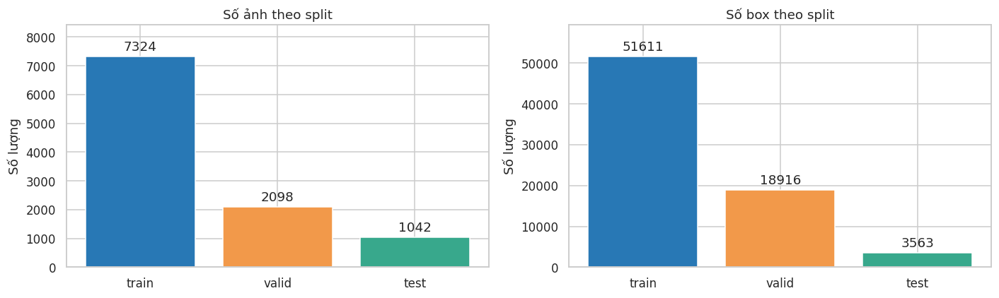

In [ ]:
# 7. QUY MÔ VÀ CÁCH CHIA TRAIN / VALIDATION / TEST
summary_rows = []
for split in SPLITS:
    imgs = image_df.loc[image_df["split"] == split]
    boxes = attached_df.loc[attached_df["split"] == split]
    n = len(imgs)
    summary_rows.append({
        "split": split, "so_anh": n, "ty_le_anh_%": 100 * n / len(image_df),
        "so_box": len(boxes), "ty_le_box_%": 100 * len(boxes) / max(len(attached_df), 1),
        "box_moi_anh": imgs["num_objects_in_img"].mean(),
        "trung_vi_box": imgs["num_objects_in_img"].median(),
        "so_anh_da_lop": int(imgs["is_multiclass"].sum()),
        "anh_da_lop_%": 100 * imgs["is_multiclass"].mean(),
        "anh_khong_doc_duoc": int((~imgs["image_readable"]).sum()),
        "anh_thieu_file_nhan": int((~imgs["label_exists"]).sum()),
        "anh_khong_co_box_doc_duoc": int((imgs["num_objects_in_img"] == 0).sum())
    })
split_summary = pd.DataFrame(summary_rows).set_index("split")
display(split_summary.round(3))
print(f"Toàn bộ: {len(image_df):,} ảnh, {len(attached_df):,} box; "
      f"trung bình {image_df['num_objects_in_img'].mean():.2f} box/ảnh.")

image_size_table = (image_df.groupby(["split", "img_w", "img_h"], dropna=False)
                    .size().rename("so_anh").reset_index())
display(image_size_table)
print(f"Dung lượng các tệp ảnh: {image_df['file_bytes'].sum() / 1024**2:.2f} MiB.")
print("Kích thước trên được đọc từ ảnh thực tế. Ảnh 416×416 không tự chứng minh đã bị Stretch;")
print("cần đối chiếu cấu hình preprocessing trên Roboflow để xác nhận phương pháp resize.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, column, title in zip(axes, ["so_anh", "so_box"], ["Số ảnh theo split", "Số box theo split"]):
    values = split_summary[column]
    bars = ax.bar(SPLITS, values, color=[SPLIT_COLORS[s] for s in SPLITS])
    ax.bar_label(bars, fmt="%.0f", padding=3)
    ax.set_title(title)
    ax.set_ylabel("Số lượng")
    ax.margins(y=0.15)
finish_figure(fig, "01_dataset_size.png")

In [ ]:
# 8. EDA PHÂN BỐ NHÃN — đếm cả số box và số ảnh chứa lớp.
class_counts = (pd.crosstab(class_df["class_name"], class_df["split"])
                .reindex(index=class_names, columns=SPLITS, fill_value=0).astype(int))
class_table = class_counts.copy()
class_table["tong"] = class_table.sum(axis=1)
class_table["ty_le_%"] = class_table["tong"] / max(class_table["tong"].sum(), 1) * 100
class_percent = class_counts.div(class_counts.sum(axis=0).replace(0, np.nan), axis=1) * 100
class_presence = class_df.drop_duplicates(["image_key", "class_name"])
class_image_counts = (pd.crosstab(class_presence["class_name"], class_presence["split"])
                      .reindex(index=class_names, columns=SPLITS, fill_value=0).astype(int))
print("Số bounding box theo lớp và split:")
display(class_table.round(2))
print("Tỷ trọng bounding box trong từng split (%):")
display(class_percent.round(2))
print("Số ảnh có xuất hiện mỗi lớp (một ảnh đa lớp được tính ở nhiều dòng):")
display(class_image_counts)

totals = class_table["tong"]
nonzero_totals = totals[totals > 0]
if not nonzero_totals.empty:
    majority_class = nonzero_totals.idxmax()
    minority_class = nonzero_totals.idxmin()
    imbalance_ratio = nonzero_totals.max() / nonzero_totals.min()
    print(f"Lớp nhiều box nhất: {majority_class} ({class_table.loc[majority_class, 'ty_le_%']:.2f}%).")
    print(f"Tỷ số lớp nhiều nhất/ít nhất trong các lớp có dữ liệu: {imbalance_ratio:.2f} lần.")
else:
    majority_class, minority_class, imbalance_ratio = None, None, np.nan
for split in SPLITS:
    absent = class_counts.index[class_counts[split].eq(0)].tolist()
    print(f"{split}: lớp không có box = {absent or 'không có'}.")
print("Lớp không xuất hiện trong test không thể được đánh giá AP một cách có ý nghĩa trên test này.")

Số bounding box theo lớp và split:


split,train,valid,test,tong,ty_le_%
class_name,,,,,
BIODEGRADABLE,31721,13637,49,45407,61.29
CARDBOARD,3386,1292,20,4698,6.34
GLASS,5429,2380,0,7809,10.54
METAL,3948,1360,533,5841,7.88
PAPER,2981,33,1376,4390,5.93
PLASTIC,4146,214,1585,5945,8.02


Tỷ trọng bounding box trong từng split (%):


split,train,valid,test
class_name,,,
BIODEGRADABLE,61.46,72.09,1.38
CARDBOARD,6.56,6.83,0.56
GLASS,10.52,12.58,0.00
METAL,7.65,7.19,14.96
PAPER,5.78,0.17,38.62
PLASTIC,8.03,1.13,44.48


Số ảnh có xuất hiện mỗi lớp (một ảnh đa lớp được tính ở nhiều dòng):


split,train,valid,test
class_name,,,
BIODEGRADABLE,1603,676,8
CARDBOARD,1053,438,11
GLASS,1879,805,0
METAL,1328,398,172
PAPER,1238,15,515
PLASTIC,1019,91,354


Lớp nhiều box nhất: BIODEGRADABLE (61.29%).
Tỷ số lớp nhiều nhất/ít nhất trong các lớp có dữ liệu: 10.34 lần.
train: lớp không có box = không có.
valid: lớp không có box = không có.
test: lớp không có box = ['GLASS'].
Lớp không xuất hiện trong test không thể được đánh giá AP một cách có ý nghĩa trên test này.


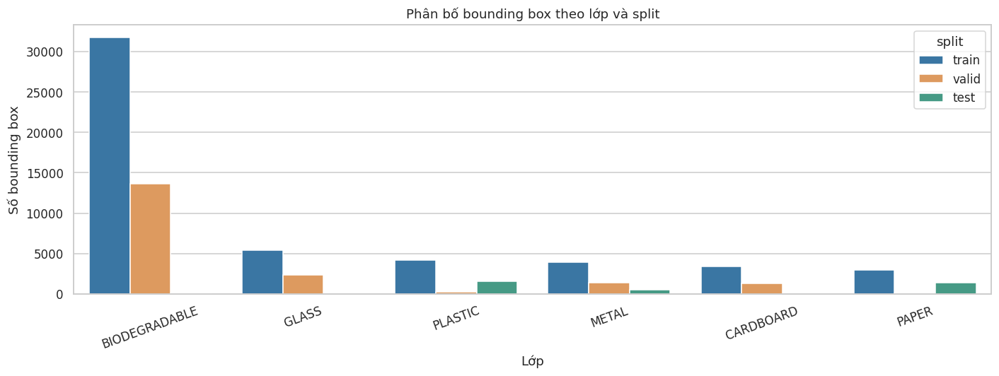

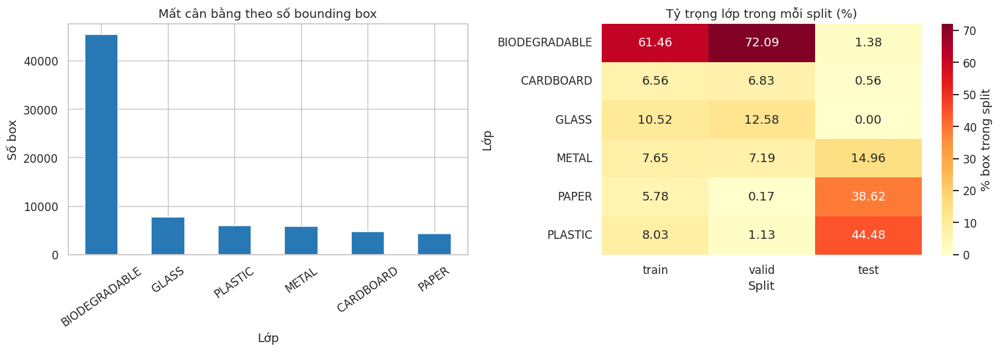

Mức khác biệt phân phối lớp giữa các split (total variation):


,train,valid,test
train,0.000,0.130,0.766
valid,0.130,0.000,0.896
test,0.766,0.896,0.000


In [ ]:
# 9. BIỂU ĐỒ PHÂN BỐ LỚP — giữ grouped countplot của notebook gốc.
order = class_table["tong"].sort_values(ascending=False).index.tolist()
if not class_df.empty:
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.countplot(data=class_df, x="class_name", hue="split", order=order,
                  hue_order=SPLITS, palette=SPLIT_COLORS, ax=ax)
    ax.set(xlabel="Lớp", ylabel="Số bounding box", title="Phân bố bounding box theo lớp và split")
    ax.tick_params(axis="x", rotation=20)
    finish_figure(fig, "02_class_countplot.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_table.loc[order, "tong"].plot.bar(ax=axes[0], color="#2878b5")
axes[0].set(title="Mất cân bằng theo số bounding box", xlabel="Lớp", ylabel="Số box")
axes[0].tick_params(axis="x", rotation=35)
sns.heatmap(class_percent.fillna(0), annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "% box trong split"}, ax=axes[1])
axes[1].set(title="Tỷ trọng lớp trong mỗi split (%)", xlabel="Split", ylabel="Lớp")
finish_figure(fig, "03_class_split_distribution.png")

tv_distance = pd.DataFrame(np.nan, index=SPLITS, columns=SPLITS)
for left in SPLITS:
    for right in SPLITS:
        if class_counts[left].sum() and class_counts[right].sum():
            tv_distance.loc[left, right] = (
                class_percent[left].sub(class_percent[right]).abs().sum() / 200
            )
print("Mức khác biệt phân phối lớp giữa các split (total variation):")
display(tv_distance.round(3))

,count,mean,std,min,25%,50%,75%,95%,99%,max
split,,,,,,,,,,
train,7324.0,7.05,19.34,1.0,1.0,2.0,5.0,31.00,92.00,358.0
valid,2098.0,9.02,21.66,1.0,1.0,2.0,6.0,45.15,104.21,311.0
test,1042.0,3.42,8.36,1.0,1.0,1.0,3.0,10.95,37.59,119.0


Trung vị toàn bộ: 2.0; trung bình: 7.08; lớn nhất: 358 box/ảnh.
Ngưỡng p99 = 91.00; có 104 ảnh vượt ngưỡng để ưu tiên duyệt.
Đây là nhóm ảnh dày đặc cần xem thêm, không phải kết luận nhãn sai.


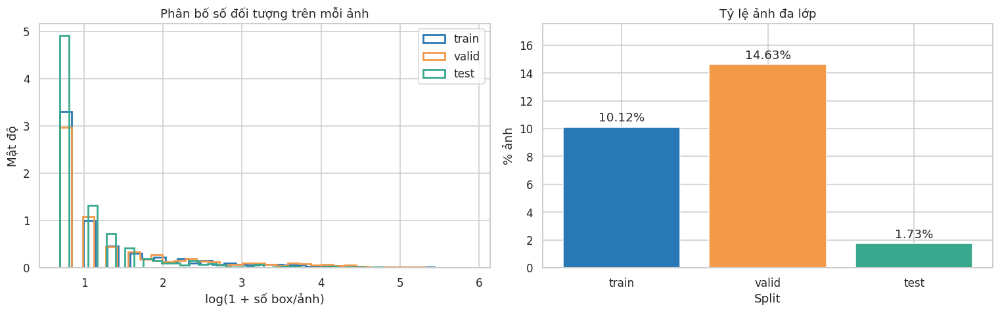

In [ ]:
# 10. MẬT ĐỘ ĐỐI TƯỢNG / ẢNH VÀ ĐỘ PHỨC TẠP CỦA TỪNG SPLIT
object_stats = image_df.groupby("split")["num_objects_in_img"].describe(
    percentiles=[.25, .5, .75, .95, .99]).reindex(SPLITS)
display(object_stats.round(2))
dense_threshold = float(image_df["num_objects_in_img"].quantile(.99))
dense_images = image_df.loc[image_df["num_objects_in_img"] > dense_threshold].copy()
print(f"Trung vị toàn bộ: {image_df['num_objects_in_img'].median():.1f}; "
      f"trung bình: {image_df['num_objects_in_img'].mean():.2f}; "
      f"lớn nhất: {image_df['num_objects_in_img'].max()} box/ảnh.")
print(f"Ngưỡng p99 = {dense_threshold:.2f}; có {len(dense_images)} ảnh vượt ngưỡng để ưu tiên duyệt.")
print("Đây là nhóm ảnh dày đặc cần xem thêm, không phải kết luận nhãn sai.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for split in SPLITS:
    subset = image_df.loc[image_df["split"] == split, "num_objects_in_img"]
    if len(subset):
        axes[0].hist(np.log1p(subset), bins=35, histtype="step", density=True,
                     label=split, color=SPLIT_COLORS[split], linewidth=1.8)
axes[0].set(xlabel="log(1 + số box/ảnh)", ylabel="Mật độ", title="Phân bố số đối tượng trên mỗi ảnh")
axes[0].legend()
bars = axes[1].bar(SPLITS, split_summary["anh_da_lop_%"], color=[SPLIT_COLORS[s] for s in SPLITS])
axes[1].bar_label(bars, fmt="%.2f%%", padding=3)
axes[1].set(title="Tỷ lệ ảnh đa lớp", xlabel="Split", ylabel="% ảnh")
axes[1].margins(y=.2)
finish_figure(fig, "04_objects_per_image.png")

In [ ]:
# 11. KÍCH THƯỚC BOUNDING BOX — tách số liệu thô và tập đủ điều kiện cho biểu đồ.
geometry_columns = ["bbox_w", "bbox_h", "bbox_area"]
finite_df = attached_df.loc[attached_df["finite_geometry"]].copy()
raw_nonnegative = finite_df.loc[(finite_df["bbox_w"] >= 0) & (finite_df["bbox_h"] >= 0)]
print("Thống kê hình học thô (tọa độ hữu hạn; có thể bao gồm box lỗi):")
display(finite_df[geometry_columns].describe(percentiles=[.25, .5, .75, .95, .99]).round(6))
print("Thống kê trên box ghép ảnh, đúng lớp và đúng hình học:")
geometry_stats = valid_df[geometry_columns + ["aspect_ratio"]].describe(
    percentiles=[.25, .5, .75, .95, .99])
display(geometry_stats.round(6))
area_by_split = valid_df.groupby("split")["bbox_area"].agg(["count", "mean", "median", "min", "max"])
display(area_by_split.reindex(SPLITS).round(6))

threshold_rows = []
for scope, frame in [("Thô, w/h không âm (kể cả bằng 0)", raw_nonnegative),
                     ("Nhãn và hình học hợp lệ", valid_df)]:
    for label, mask in [("Diện tích < 0.1% ảnh", frame["bbox_area"] < .001),
                        ("Diện tích < 1% ảnh", frame["bbox_area"] < .01),
                        ("Diện tích >= 90% ảnh", frame["bbox_area"] >= .9)]:
        threshold_rows.append({"pham_vi": scope, "nguong": label, "so_box": int(mask.sum()),
                               "mau_so": len(frame), "ty_le_%": 100 * mask.mean() if len(frame) else np.nan})
area_thresholds = pd.DataFrame(threshold_rows)
display(area_thresholds.round(3))
print("Các ngưỡng trên là tỷ lệ diện tích ảnh tự chọn cho EDA, không phải chuẩn small/medium/large của COCO.")
print("Hai nhóm <0.1% và <1% lồng nhau; không cộng chúng thành một tổng.")

Thống kê hình học thô (tọa độ hữu hạn; có thể bao gồm box lỗi):


,bbox_w,bbox_h,bbox_area
count,74090.000000,74090.000000,74090.000000
mean,0.230166,0.246125,0.099887
std,0.238934,0.247158,0.193297
min,0.000000,0.000000,0.000000
25%,0.069712,0.074519,0.005501
50%,0.134615,0.146635,0.019878
75%,0.290865,0.317308,0.088197
95%,0.826923,0.848558,0.547579
99%,0.997596,0.995192,0.990408
max,1.000000,1.000000,0.995198


Thống kê trên box ghép ảnh, đúng lớp và đúng hình học:


,bbox_w,bbox_h,bbox_area,aspect_ratio
count,74073.000000,74073.000000,74073.000000,74073.000000
mean,0.230202,0.246180,0.099910,1.166719
std,0.238925,0.247159,0.193313,1.017407
min,0.003606,0.003606,0.000023,0.026667
25%,0.069712,0.074519,0.005501,0.619048
50%,0.134615,0.146635,0.019901,0.926316
75%,0.290865,0.317308,0.088203,1.393939
95%,0.826923,0.848558,0.547626,2.761442
99%,0.997596,0.995192,0.990408,5.014887
max,1.000000,1.000000,0.995198,42.363636


,count,mean,median,min,max
split,,,,,
train,51601,0.100365,0.020155,0.000023,0.995198
valid,18910,0.076115,0.015521,0.000035,0.995198
test,3562,0.219641,0.087779,0.000260,0.995198


,pham_vi,nguong,so_box,mau_so,ty_le_%
0,"Thô, w/h không âm (kể cả bằng 0)",Diện tích < 0.1% ảnh,2285,74090,3.084
1,"Thô, w/h không âm (kể cả bằng 0)",Diện tích < 1% ảnh,27014,74090,36.461
2,"Thô, w/h không âm (kể cả bằng 0)",Diện tích >= 90% ảnh,1398,74090,1.887
3,Nhãn và hình học hợp lệ,Diện tích < 0.1% ảnh,2268,74073,3.062
4,Nhãn và hình học hợp lệ,Diện tích < 1% ảnh,26997,74073,36.446
5,Nhãn và hình học hợp lệ,Diện tích >= 90% ảnh,1398,74073,1.887


Các ngưỡng trên là tỷ lệ diện tích ảnh tự chọn cho EDA, không phải chuẩn small/medium/large của COCO.
Hai nhóm <0.1% và <1% lồng nhau; không cộng chúng thành một tổng.


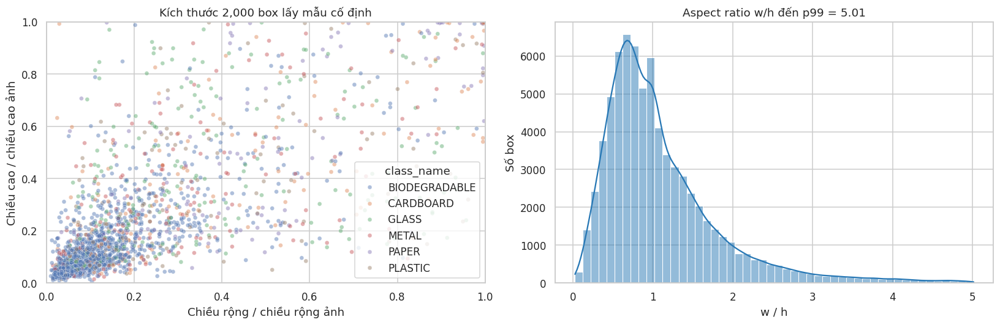

Không dùng 17 box lỗi nhãn/hình học trong các biểu đồ này.
Histogram chỉ hiển thị đến p99; 741 box ngoài khung vẫn được giữ trong bảng thống kê/CSV.
Aspect ratio lớn nhất thực tế trong tập hợp lệ: 42.364.


In [ ]:
# 12. SCATTER WIDTH/HEIGHT VÀ ASPECT RATIO — kế thừa notebook gốc, tránh chia cho h=0.
if not valid_df.empty:
    sampled = valid_df.sample(n=min(2000, len(valid_df)), random_state=SEED)
    ratios = valid_df["aspect_ratio"]
    ratio_p99 = float(ratios.quantile(.99))
    ratio_display = ratios.loc[ratios <= ratio_p99]
    hidden = int((ratios > ratio_p99).sum())
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.scatterplot(data=sampled, x="bbox_w", y="bbox_h", hue="class_name", hue_order=class_names,
                    alpha=.45, s=20, ax=axes[0])
    axes[0].set(title=f"Kích thước {len(sampled):,} box lấy mẫu cố định", xlabel="Chiều rộng / chiều rộng ảnh",
                ylabel="Chiều cao / chiều cao ảnh", xlim=(0, 1), ylim=(0, 1))
    sns.histplot(ratio_display, bins=50, kde=ratio_display.nunique() > 1, ax=axes[1], color="#2878b5")
    axes[1].set(title=f"Aspect ratio w/h đến p99 = {ratio_p99:.2f}", xlabel="w / h", ylabel="Số box")
    finish_figure(fig, "05_bbox_scatter_aspect_ratio.png")
    print(f"Không dùng {len(attached_df) - len(valid_df):,} box lỗi nhãn/hình học trong các biểu đồ này.")
    print(f"Histogram chỉ hiển thị đến p99; {hidden:,} box ngoài khung vẫn được giữ trong bảng thống kê/CSV.")
    print(f"Aspect ratio lớn nhất thực tế trong tập hợp lệ: {ratios.max():.3f}.")
else:
    print("Không có box hợp lệ để vẽ kích thước/tỷ lệ cạnh.")

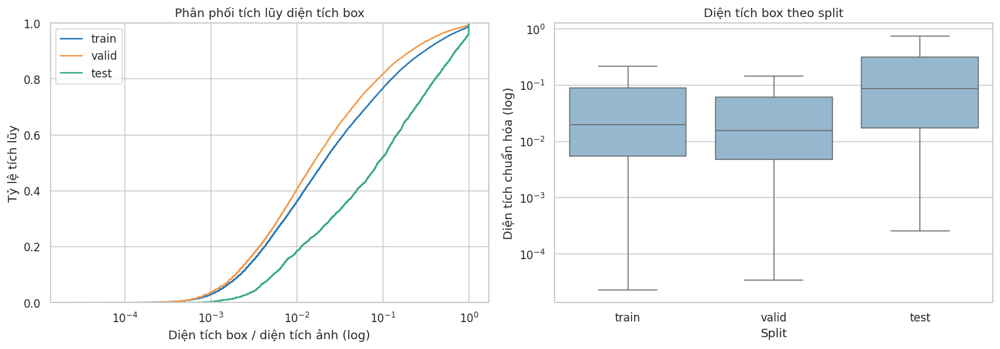

Boxplot ẩn điểm ngoài whisker để dễ đọc; ECDF và CSV vẫn sử dụng toàn bộ box hợp lệ.
Nếu test chứa box lớn hơn và ít đối tượng/ảnh hơn, cần đánh giá thêm mức khác biệt độ khó;
không thể kết luận mô hình tốt/kém chỉ từ biểu đồ EDA.


In [ ]:
# 13. SO SÁNH DIỆN TÍCH BOX GIỮA CÁC SPLIT
if not valid_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for split in SPLITS:
        area = valid_df.loc[valid_df["split"] == split, "bbox_area"]
        if len(area):
            sns.ecdfplot(x=area, ax=axes[0], label=split, color=SPLIT_COLORS[split])
    axes[0].set_xscale("log")
    axes[0].set(title="Phân phối tích lũy diện tích box", xlabel="Diện tích box / diện tích ảnh (log)",
                ylabel="Tỷ lệ tích lũy")
    axes[0].legend()
    sns.boxplot(data=valid_df, x="split", y="bbox_area", order=SPLITS, showfliers=False,
                color="#8bbad9", ax=axes[1])
    axes[1].set_yscale("log")
    axes[1].set(title="Diện tích box theo split", xlabel="Split", ylabel="Diện tích chuẩn hóa (log)")
    finish_figure(fig, "06_bbox_area_by_split.png")
    print("Boxplot ẩn điểm ngoài whisker để dễ đọc; ECDF và CSV vẫn sử dụng toàn bộ box hợp lệ.")
    print("Nếu test chứa box lớn hơn và ít đối tượng/ảnh hơn, cần đánh giá thêm mức khác biệt độ khó;")
    print("không thể kết luận mô hình tốt/kém chỉ từ biểu đồ EDA.")

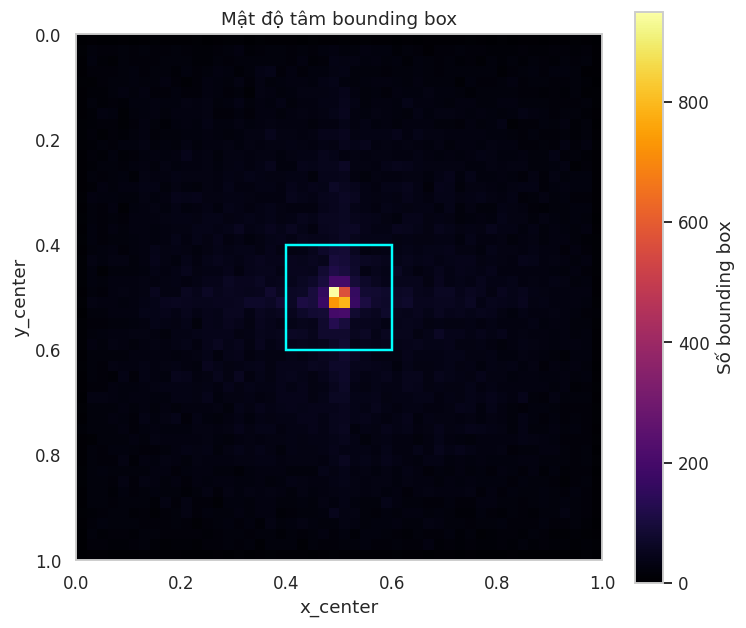

Vùng trung tâm [0.4, 0.6]²: 9,999/74,090 tâm (13.50%).
Vùng này chiếm 4% diện tích ảnh. Chênh lệch so với 4% là dấu hiệu tập trung tâm, không phải kiểm định.
Heatmap dùng box có tọa độ hữu hạn và tâm nằm trong ảnh, kể cả box có w/h=0 để đối chiếu số liệu thô.


In [ ]:
# 14. HEATMAP TÂM BOUNDING BOX — giữ nội dung của notebook gốc.
center_source = finite_df.loc[finite_df["x_center"].between(0, 1) & finite_df["y_center"].between(0, 1)]
center_mask = center_source["x_center"].between(.4, .6) & center_source["y_center"].between(.4, .6)
center_percent = 100 * center_mask.mean() if len(center_source) else np.nan
if not center_source.empty:
    fig, ax = plt.subplots(figsize=(7, 6))
    hist = ax.hist2d(center_source["x_center"], center_source["y_center"], bins=50,
                     range=[[0, 1], [0, 1]], cmap="inferno")
    ax.add_patch(patches.Rectangle((.4, .4), .2, .2, fill=False, edgecolor="cyan", linewidth=1.6))
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set(title="Mật độ tâm bounding box", xlabel="x_center", ylabel="y_center")
    fig.colorbar(hist[3], ax=ax, label="Số bounding box")
    finish_figure(fig, "07_bbox_center_heatmap.png")
print(f"Vùng trung tâm [0.4, 0.6]²: {int(center_mask.sum()):,}/{len(center_source):,} tâm ({center_percent:.2f}%).")
print("Vùng này chiếm 4% diện tích ảnh. Chênh lệch so với 4% là dấu hiệu tập trung tâm, không phải kiểm định.")
print("Heatmap dùng box có tọa độ hữu hạn và tâm nằm trong ảnh, kể cả box có w/h=0 để đối chiếu số liệu thô.")

In [ ]:
# 15. CHẤT LƯỢNG ANNOTATION VÀ GHÉP CẶP ẢNH–NHÃN
invalid_boxes = box_df.loc[~box_df["annotation_valid"]].copy()
duplicate_columns = ["image_key", "class_id", "x_center", "y_center", "bbox_w", "bbox_h"]
duplicate_boxes = attached_df.loc[attached_df.duplicated(duplicate_columns, keep=False)].copy()
duplicate_extra_rows = int(attached_df.duplicated(duplicate_columns, keep="first").sum())
quality_rows = []
for split in SPLITS:
    subset = box_df.loc[box_df["split"] == split]
    labels = label_df.loc[label_df["split"] == split]
    imgs = image_df.loc[image_df["split"] == split]
    quality_rows.append({
        "split": split, "box_loi_phan_biet": int((~subset["annotation_valid"]).sum()),
        "w_bang_0": int(subset["zero_width"].sum()), "h_bang_0": int(subset["zero_height"].sum()),
        "w_am": int((subset["bbox_w"] < 0).sum()), "h_am": int((subset["bbox_h"] < 0).sum()),
        "box_vuot_bien": int(subset["out_of_bounds"].sum()),
        "class_id_loi": int((~subset["class_valid"]).sum()),
        "toa_do_khong_huu_han": int((~subset["finite_geometry"]).sum()),
        "file_nhan_rong": int(labels["n_nonblank_lines"].eq(0).sum()),
        "anh_thieu_file_nhan": int((~imgs["label_exists"]).sum()),
        "file_nhan_khong_co_anh": int(labels["n_images"].eq(0).sum())
    })
quality_summary = pd.DataFrame(quality_rows).set_index("split")
display(quality_summary)
print(f"Có {len(invalid_boxes):,}/{len(box_df):,} dòng 5 số có class ID hoặc hình học không hợp lệ.")
print(f"Số dòng annotation trùng hoàn toàn dư ra trong cùng ảnh: {duplicate_extra_rows:,}.")
print("Một box có thể gặp nhiều lỗi; không cộng các cột lỗi để suy ra số box lỗi phân biệt.")
print("Dòng sai số cột/không đọc được số không nằm trong box_df, được thống kê riêng dưới đây.")
issue_summary = (issues_df.groupby(["issue", "split"]).size().unstack(fill_value=0)
                 .reindex(columns=SPLITS, fill_value=0))
display(issue_summary)
if not invalid_boxes.empty:
    display(invalid_boxes[["split", "file_name", "line_no", "class_name", "bbox_w", "bbox_h", "invalid_reasons"]].head(20))

,box_loi_phan_biet,w_bang_0,h_bang_0,w_am,h_am,box_vuot_bien,class_id_loi,toa_do_khong_huu_han,file_nhan_rong,anh_thieu_file_nhan,file_nhan_khong_co_anh
split,,,,,,,,,,,
train,10,4,6,0,0,0,0,0,0,0,0
valid,6,2,4,0,0,0,0,0,0,0,0
test,1,1,0,0,0,0,0,0,0,0,0


Có 17/74,090 dòng 5 số có class ID hoặc hình học không hợp lệ.
Số dòng annotation trùng hoàn toàn dư ra trong cùng ảnh: 0.
Một box có thể gặp nhiều lỗi; không cộng các cột lỗi để suy ra số box lỗi phân biệt.
Dòng sai số cột/không đọc được số không nằm trong box_df, được thống kê riêng dưới đây.


split,train,valid,test
issue,,,
non_positive_height,6,4,0
non_positive_width,4,2,1


,split,file_name,line_no,class_name,bbox_w,bbox_h,invalid_reasons
5449,train,biodegradable1465_jpg.rf.6554b314de4df3aed0117f0283e9df7f.jpg,54,BIODEGRADABLE,0.012019,0.000000,non_positive_height
9751,train,biodegradable1740_jpg.rf.5f00e1157464c17341765a596a148298.jpg,64,BIODEGRADABLE,0.000000,0.043269,non_positive_width
13817,train,biodegradable1998_jpeg.rf.17921ee65cee3e00f10a24d639dff35b.jpg,261,BIODEGRADABLE,0.062500,0.000000,non_positive_height
14182,train,biodegradable2012_jpeg.rf.f157a4549b3da5de53b7d15eb8ed051d.jpg,26,BIODEGRADABLE,0.004808,0.000000,non_positive_height
20098,train,biodegradable366_jpg.rf.09e6cd29dee38feb3b4df80653e5fb0f.jpg,18,BIODEGRADABLE,0.048077,0.000000,non_positive_height
22020,train,biodegradable419_jpg.rf.3cb6ccbe84af9a0d1a083252e479def4.jpg,32,BIODEGRADABLE,0.004808,0.000000,non_positive_height
22182,train,biodegradable421_jpg.rf.0d8bc76989848c2d9173e3c49c133867.jpg,94,BIODEGRADABLE,0.000000,0.007212,non_positive_width
34866,train,cardboard895_jpg.rf.9fe0d5e9a4d71705fa33323a01dcc534.jpg,3,CARDBOARD,0.000000,0.004808,non_positive_width
46522,train,paper1805_jpeg.rf.3cbe8e415d51c085ff0165a12cea5880.jpg,1,PAPER,0.000000,0.004808,non_positive_width
47560,train,paper787_jpg.rf.a776cf355b31868a4cfda6ff51850600.jpg,1,PAPER,0.004808,0.000000,non_positive_height


Số ảnh theo tiền tố tên tệp và split:


split,train,valid,test
filename_prefix,,,
biodegradable,1554,666,0
cardboard,1006,433,0
glass,1854,795,0
metal,874,204,170
paper,1223,0,523
plastic,813,0,349


Tỷ lệ phân chia bên trong từng nhóm tiền tố (%):


split,train,valid,test
filename_prefix,,,
biodegradable,70.00,30.00,0.00
cardboard,69.91,30.09,0.00
glass,69.99,30.01,0.00
metal,70.03,16.35,13.62
paper,70.05,0.00,29.95
plastic,69.97,0.00,30.03


Có 39 ảnh bất đồng tiền tố/annotation, trên 10,464 ảnh có thể kiểm tra; chiếm 0.373% toàn bộ ảnh.


,split,file_name,prefix_class,classes_in_img
278,train,biodegradable1354_jpg.rf.9b87634a17ad5e0d12206829582f16d9.jpg,BIODEGRADABLE,[PAPER]
321,train,biodegradable1408_jpg.rf.7c79b8c37bc27b860e14a2806bc25d5b.jpg,BIODEGRADABLE,[PAPER]
330,train,biodegradable1416_jpg.rf.479b5954a15f931039b6bca0a85052c5.jpg,BIODEGRADABLE,[PAPER]
1331,train,biodegradable695_jpg.rf.26c6542a1e62f4c74d179f9a74cc2b13.jpg,BIODEGRADABLE,[PLASTIC]
1625,train,cardboard1099_jpeg.rf.0b5e1b1d1570363e62d6a944f3e0069e.jpg,CARDBOARD,[PAPER]
1895,train,cardboard1478_jpeg.rf.143177b8188cf0f92ce584e2b71c34d2.jpg,CARDBOARD,[PAPER]
2896,train,glass1429_jpg.rf.733a1abad7d772631a43b487831be0c5.jpg,GLASS,[PLASTIC]
2962,train,glass1511_jpg.rf.55ea9527ab3fd604d6c2db6afaa6466d.jpg,GLASS,[PLASTIC]
4320,train,glass854_jpg.rf.7fc3e51da86497dbaba95d6bae2f61ff.jpg,GLASS,[METAL]
4668,train,metal192_jpg.rf.39b666c278319e96915da0f23c026d65.jpg,METAL,[BIODEGRADABLE]


Đây là danh sách cần xem thủ công, KHÔNG phải số ảnh đã được xác nhận gán nhãn sai.
Nhóm nguồn chỉ được suy ra từ tên tệp; không chứng minh chính xác quy trình chia tập ban đầu.


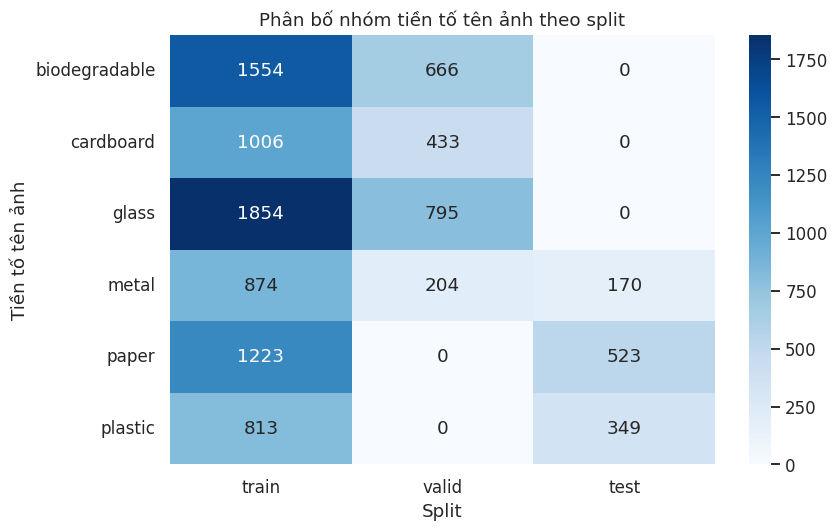

In [ ]:
# 16. TIỀN TỐ TÊN TỆP VÀ KHÁC BIỆT NHÓM NGUỒN — không coi tên tệp là ground truth.
prefix_to_class = {name.casefold(): name for name in class_names}
image_df["prefix_class"] = image_df["filename_prefix"].map(prefix_to_class)
image_df["prefix_checkable"] = image_df["prefix_class"].notna() & image_df["num_classes_in_img"].gt(0)
image_df["prefix_mismatch"] = image_df.apply(
    lambda row: bool(row["prefix_checkable"] and row["prefix_class"] not in row["classes_in_img"]), axis=1)
prefix_mismatches = image_df.loc[image_df["prefix_mismatch"]].copy()
prefix_split = pd.crosstab(image_df["filename_prefix"], image_df["split"]).reindex(columns=SPLITS, fill_value=0)
print("Số ảnh theo tiền tố tên tệp và split:")
display(prefix_split)
print("Tỷ lệ phân chia bên trong từng nhóm tiền tố (%):")
display(prefix_split.div(prefix_split.sum(axis=1), axis=0).mul(100).round(2))
print(f"Có {len(prefix_mismatches):,} ảnh bất đồng tiền tố/annotation, "
      f"trên {int(image_df['prefix_checkable'].sum()):,} ảnh có thể kiểm tra; "
      f"chiếm {100 * len(prefix_mismatches) / len(image_df):.3f}% toàn bộ ảnh.")
display(prefix_mismatches[["split", "file_name", "prefix_class", "classes_in_img"]].head(20))
print("Đây là danh sách cần xem thủ công, KHÔNG phải số ảnh đã được xác nhận gán nhãn sai.")
print("Nhóm nguồn chỉ được suy ra từ tên tệp; không chứng minh chính xác quy trình chia tập ban đầu.")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(prefix_split, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set(title="Phân bố nhóm tiền tố tên ảnh theo split", xlabel="Split", ylabel="Tiền tố tên ảnh")
finish_figure(fig, "08_filename_prefix_split.png")

In [ ]:
# 17. KIỂM TRA ẢNH TRÙNG VÀ NGUY CƠ RÒ RỈ GIỮA CÁC SPLIT
def duplicate_image_groups(frame, column):
    available = frame.loc[frame[column].notna() & frame[column].ne("")].copy()
    groups = available.groupby(column).agg(
        so_anh=("image_key", "size"), so_split=("split", "nunique"),
        splits=("split", lambda values: ", ".join(sorted(set(values)))),
        image_keys=("image_key", lambda values: " | ".join(values))
    )
    return groups.loc[groups["so_anh"] > 1].reset_index()


original_groups = duplicate_image_groups(image_df, "original_id")
hash_groups = duplicate_image_groups(image_df, "sha256")
cross_original = original_groups.loc[original_groups["so_split"] > 1]
cross_hash = hash_groups.loc[hash_groups["so_split"] > 1]
hash_coverage = int(image_df["sha256"].notna().sum())
print(f"Nhóm trùng ID tên nguồn (heuristic): {len(original_groups)}; đi qua nhiều split: {len(cross_original)}.")
if CHECK_BYTE_DUPLICATES:
    print(f"Đã tính SHA-256 cho {hash_coverage:,}/{len(image_df):,} ảnh.")
    print(f"Nhóm ảnh trùng byte: {len(hash_groups)}; đi qua nhiều split: {len(cross_hash)}.")
else:
    print("Chưa kiểm tra trùng byte vì CHECK_BYTE_DUPLICATES=False; không được kết luận 'không có ảnh trùng'.")
display(cross_original.head(15))
display(cross_hash.head(15))
print("Không phát hiện trùng byte/ID không đồng nghĩa không có ảnh gần trùng do crop, lật, xoay hoặc nén.")
print("Perceptual hash/embedding và duyệt thủ công là hướng kiểm tra thêm, chưa thực hiện trong notebook này.")

Nhóm trùng ID tên nguồn (heuristic): 0; đi qua nhiều split: 0.
Đã tính SHA-256 cho 10,464/10,464 ảnh.
Nhóm ảnh trùng byte: 0; đi qua nhiều split: 0.


,original_id,so_anh,so_split,splits,image_keys


,sha256,so_anh,so_split,splits,image_keys


Không phát hiện trùng byte/ID không đồng nghĩa không có ảnh gần trùng do crop, lật, xoay hoặc nén.
Perceptual hash/embedding và duyệt thủ công là hướng kiểm tra thêm, chưa thực hiện trong notebook này.


In [ ]:
# 18. HÀM XEM ẢNH VÀ BOUNDING BOX — kế thừa phần hiển thị mẫu ngẫu nhiên của notebook gốc.
# Dùng Pillow/Matplotlib để hiển thị; không cần ghi ảnh đã vẽ vào dataset.
class_colors = dict(zip(class_names, sns.color_palette("husl", NC)))


def plot_samples(rows, title, filename, max_labels=50):
    if rows.empty:
        print("Không có ảnh để hiển thị:", title)
        return
    rows = rows.head(8)
    columns = min(4, len(rows))
    nrows = math.ceil(len(rows) / columns)
    fig, axes = plt.subplots(nrows, columns, figsize=(5 * columns, 4.8 * nrows), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, (_, record) in zip(axes.flat, rows.iterrows()):
        try:
            with Image.open(record["image_path"]) as source:
                img = source.convert("RGB")
        except Exception:
            ax.set_title(record["split"] + " — ảnh không đọc được")
            continue
        width, height = img.size
        ax.imshow(img)
        subset = attached_df.loc[attached_df["image_key"] == record["image_key"]]
        skipped = 0
        for i, (_, box) in enumerate(subset.iterrows()):
            if not box["finite_geometry"]:
                skipped += 1
                continue
            xc, yc = box["x_center"] * width, box["y_center"] * height
            bw, bh = box["bbox_w"] * width, box["bbox_h"] * height
            color = class_colors.get(box["class_name"], "red") if box["annotation_valid"] else "red"
            if bw > 0 and bh > 0:
                ax.add_patch(patches.Rectangle((xc - bw / 2, yc - bh / 2), bw, bh,
                                               fill=False, edgecolor=color, linewidth=1))
            else:
                ax.plot(xc, yc, "rx", markersize=7)
            if i < max_labels:
                text = box["class_name"] + (" [LOI]" if not box["annotation_valid"] else "")
                ax.text(xc - bw / 2, yc - bh / 2, text, fontsize=6, color="black",
                         bbox={"facecolor": color, "alpha": .65, "pad": 1})
        # Giới hạn hiển thị theo ảnh; không clip/sửa tọa độ trong bảng dữ liệu.
        ax.set_xlim(0, width)
        ax.set_ylim(height, 0)
        name = record["file_name"][:42]
        ax.set_title(f"{record['split']} | {name}\n{subset.shape[0]} box; {skipped} box không thể vẽ", fontsize=9)
    fig.suptitle(title + "\nMàu đỏ / dấu x: nhãn hoặc hình học lỗi; chỉ ghi tên tối đa 50 box/ảnh", y=1.02)
    finish_figure(fig, filename)

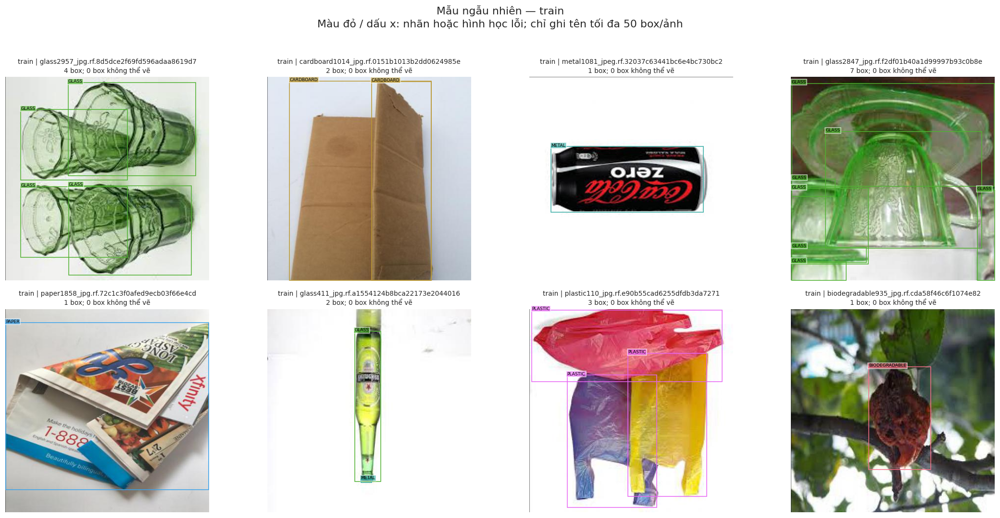

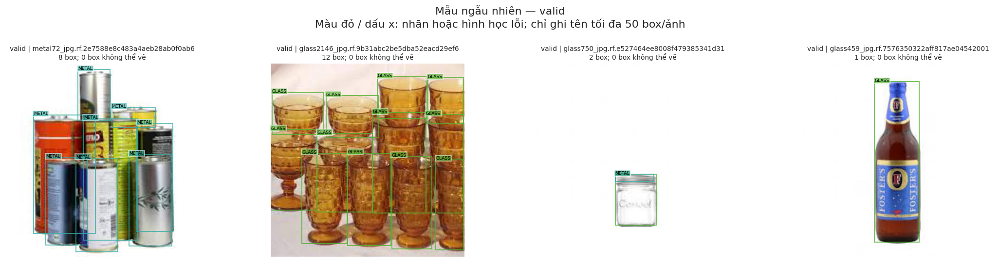

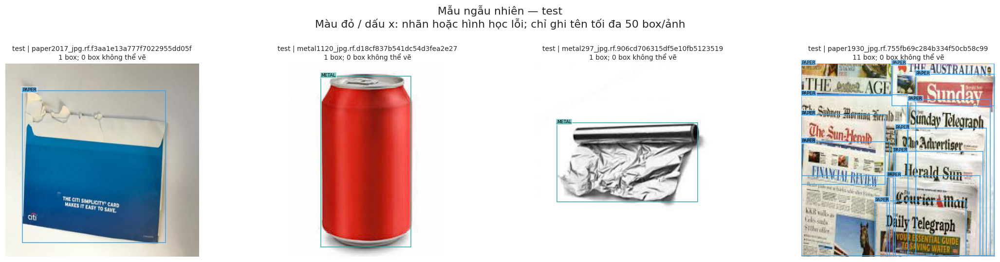

Khi quan sát: chú ý nền trắng/cảnh thực, ảnh ghép, che khuất, vật thể nhỏ, cây/thức ăn chưa thành rác.
Mẫu ngẫu nhiên hỗ trợ nhận xét định tính; không đủ để kết luận tỷ lệ miền ảnh của toàn dataset.


In [ ]:
# 19. QUAN SÁT MẪU NGẪU NHIÊN Ở CẢ TRAIN / VAL / TEST
for i, split in enumerate(SPLITS):
    candidates = image_df.loc[(image_df["split"] == split) & image_df["image_readable"]]
    n = min(8 if split == "train" else 4, len(candidates))
    selected = candidates.sample(n=n, random_state=SEED + i) if n else candidates
    plot_samples(selected, f"Mẫu ngẫu nhiên — {split}", f"09_random_{split}.png")
print("Khi quan sát: chú ý nền trắng/cảnh thực, ảnh ghép, che khuất, vật thể nhỏ, cây/thức ăn chưa thành rác.")
print("Mẫu ngẫu nhiên hỗ trợ nhận xét định tính; không đủ để kết luận tỷ lệ miền ảnh của toàn dataset.")

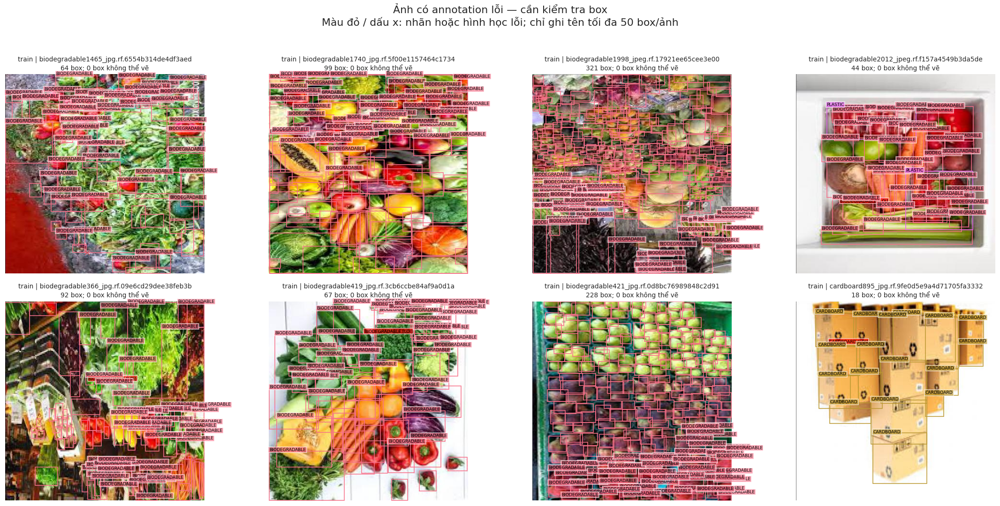

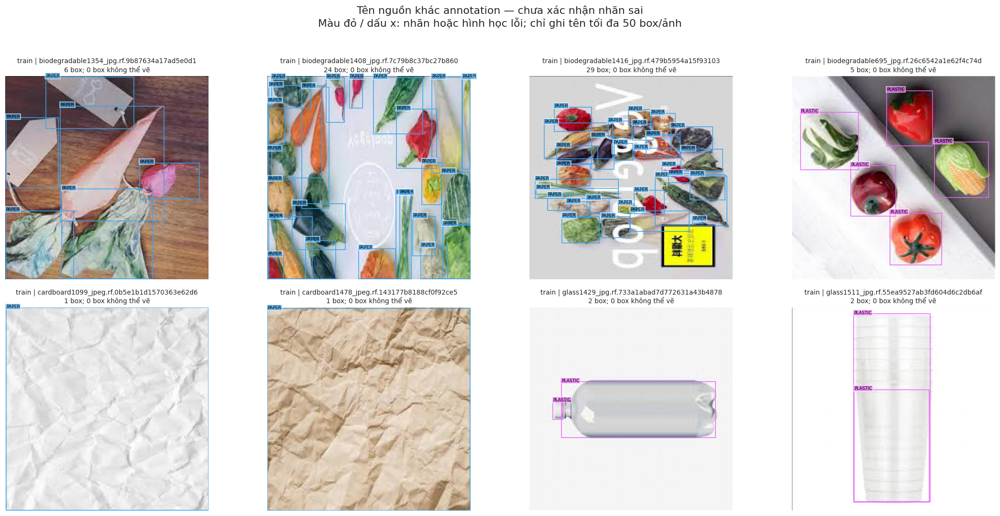

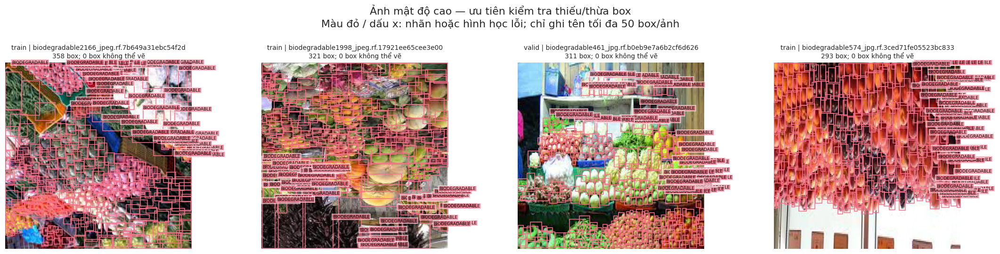

In [ ]:
# 20. XEM CÁC TRƯỜNG HỢP CẦN DUYỆT — không tự động sửa nhãn theo tên tệp.
invalid_image_keys = set(invalid_boxes.loc[invalid_boxes["has_image"], "image_key"])
invalid_image_rows = image_df.loc[image_df["image_key"].isin(invalid_image_keys) & image_df["image_readable"]]
plot_samples(invalid_image_rows, "Ảnh có annotation lỗi — cần kiểm tra box", "10_invalid_box_examples.png")
plot_samples(prefix_mismatches.loc[prefix_mismatches["image_readable"]],
              "Tên nguồn khác annotation — chưa xác nhận nhãn sai", "11_prefix_mismatch_examples.png")
plot_samples(dense_images.loc[dense_images["image_readable"]].sort_values("num_objects_in_img", ascending=False).head(4),
              "Ảnh mật độ cao — ưu tiên kiểm tra thiếu/thừa box", "12_dense_image_examples.png")

In [ ]:
# 21. LẬP DANH SÁCH DUYỆT THỦ CÔNG, KHÔNG XUẤT NHÃN ĐÃ SỬA
review_df = image_df.copy()
review_df["has_invalid_box"] = review_df["image_key"].isin(invalid_image_keys)
review_df["dense_image"] = review_df["num_objects_in_img"] > dense_threshold
review_df["duplicate_annotation"] = review_df["image_key"].isin(set(duplicate_boxes["image_key"]))
problem_files = set(zip(issues_df["split"], issues_df["file_name"]))
review_df["has_audit_issue"] = [
    (split, filename) in problem_files for split, filename in zip(review_df["split"], review_df["file_name"])
]
review_flags = ["has_invalid_box", "prefix_mismatch", "dense_image", "duplicate_annotation", "has_audit_issue"]
review_df["review_reasons"] = review_df.apply(
    lambda row: ";".join(name for name in review_flags if row[name]), axis=1)
review_queue = review_df.loc[review_df["review_reasons"].ne(""),
    ["split", "file_name", "image_path", "num_objects_in_img", "prefix_class", "classes_in_img", "review_reasons"]].copy()
review_queue["review_status"] = "chua_duyet"
review_queue["reviewer_notes"] = ""
print(f"Có {len(review_queue):,} ảnh cần ưu tiên xem lại theo một hoặc nhiều tiêu chí.")
print("Các nhãn mồ côi/dòng không đọc được nằm riêng trong audit_issues.csv; không bỏ qua chúng.")
display(review_queue.head(15))

Có 154 ảnh cần ưu tiên xem lại theo một hoặc nhiều tiêu chí.
Các nhãn mồ côi/dòng không đọc được nằm riêng trong audit_issues.csv; không bỏ qua chúng.


,split,file_name,image_path,num_objects_in_img,prefix_class,classes_in_img,review_reasons,review_status,reviewer_notes
34,train,biodegradable1042_jpg.rf.3376510dafac5208f5fdbe73aa644823.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/images/biodegradable1042_jpg.rf.3376510dafac...,192,BIODEGRADABLE,[BIODEGRADABLE],dense_image,chua_duyet,
71,train,biodegradable1098_jpg.rf.19380234f4be52a878b8c4781ac2df3e.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/images/biodegradable1098_jpg.rf.19380234f4be...,114,BIODEGRADABLE,[BIODEGRADABLE],dense_image,chua_duyet,
96,train,biodegradable1125_jpg.rf.6c47eea4ab2ac4def8115766df900e68.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/images/biodegradable1125_jpg.rf.6c47eea4ab2a...,117,BIODEGRADABLE,[BIODEGRADABLE],dense_image,chua_duyet,
104,train,biodegradable1138_jpg.rf.9be197d1f69752775ec8048c589aa59c.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/images/biodegradable1138_jpg.rf.9be197d1f697...,112,BIODEGRADABLE,[BIODEGRADABLE],dense_image,chua_duyet,
278,train,biodegradable1354_jpg.rf.9b87634a17ad5e0d12206829582f16d9.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/images/biodegradable1354_jpg.rf.9b87634a17ad...,6,BIODEGRADABLE,[PAPER],prefix_mismatch,chua_duyet,
280,train,biodegradable1357_jpg.rf.d94a4f636a90924b9c2b21551d0d4b23.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/images/biodegradable1357_jpg.rf.d94a4f636a90...,120,BIODEGRADABLE,[BIODEGRADABLE],dense_image,chua_duyet,
309,train,biodegradable1396_jpg.rf.d783dccb5e55c3f505b189475ac64be7.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/images/biodegradable1396_jpg.rf.d783dccb5e55...,147,BIODEGRADABLE,[BIODEGRADABLE],dense_image,chua_duyet,
321,train,biodegradable1408_jpg.rf.7c79b8c37bc27b860e14a2806bc25d5b.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/images/biodegradable1408_jpg.rf.7c79b8c37bc2...,24,BIODEGRADABLE,[PAPER],prefix_mismatch,chua_duyet,
330,train,biodegradable1416_jpg.rf.479b5954a15f931039b6bca0a85052c5.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/images/biodegradable1416_jpg.rf.479b5954a15f...,29,BIODEGRADABLE,[PAPER],prefix_mismatch,chua_duyet,
347,train,biodegradable1443_jpg.rf.362fa60a4f447fe900e949ee5c5603d0.jpg,/content/GARBAGE-CLASSIFICATION-3-2/train/images/biodegradable1443_jpg.rf.362fa60a4f44...,168,BIODEGRADABLE,[BIODEGRADABLE],dense_image,chua_duyet,


In [ ]:
# 22. TỔNG HỢP ĐIỂM MẠNH, ĐIỂM YẾU VÀ INSIGHTS TỪ EDA
# Phân biệt phát hiện định lượng, dấu hiệu cần kiểm tra và hạn chế của phép đo.
strengths = [
    f"Quy mô quan sát: {len(image_df):,} ảnh, {len(attached_df):,} box ghép được với ảnh, {NC} lớp trong schema.",
    "Định dạng YOLO thống nhất giúp biểu diễn vị trí và lớp của nhiều đối tượng trong một ảnh.",
    f"Có {int(image_df['is_multiclass'].sum()):,} ảnh đa lớp, hỗ trợ khảo sát cảnh chứa nhiều loại vật liệu.",
]
if duplicate_extra_rows == 0:
    strengths.append("Phép kiểm tra hiện tại không phát hiện annotation trùng hoàn toàn trong cùng ảnh.")
if CHECK_BYTE_DUPLICATES and hash_coverage == len(image_df) and cross_hash.empty:
    strengths.append("Không phát hiện ảnh trùng byte đi qua các split; chưa loại trừ ảnh gần trùng.")

findings = []
def finding(topic, evidence, implication, status="Định lượng từ EDA"):
    findings.append({"van_de": topic, "bang_chung": evidence, "y_nghia": implication, "muc_do_ket_luan": status})

if majority_class:
    finding("Mất cân bằng số box",
            f"{majority_class}: {class_table.loc[majority_class, 'ty_le_%']:.2f}%; tỷ số max/min (lớp có dữ liệu): {imbalance_ratio:.2f}.",
            "Cần xem kết quả từng lớp; số box nhiều không đồng nghĩa có nhiều ảnh độc lập.")
for split in SPLITS:
    absent = class_counts.index[class_counts[split].eq(0)].tolist()
    if absent:
        finding(f"Lớp vắng trong {split}", ", ".join(absent),
                "Split không bao phủ đầy đủ schema; không dùng nó để kết luận chất lượng lớp vắng mặt.")
finding("Khác biệt phân bố giữa các split", "Xem bảng tỷ trọng lớp, total variation, mật độ và diện tích box.",
        "Tỷ lệ ảnh 70/20/10 không bảo đảm các tập có cùng phân bố lớp và độ khó.")
finding("Annotation không hợp lệ", f"{len(invalid_boxes)} dòng 5 số lỗi nhãn/hình học; {duplicate_extra_rows} dòng trùng dư.",
        "Cần kiểm tra từng dòng lỗi; không xử lý h=0 bằng cách cộng epsilon vào aspect ratio.")
finding("Bất đồng tên tệp và annotation", f"{len(prefix_mismatches)} ảnh được gắn cờ.",
        "Tên tệp không phải ground truth; có thể annotation đúng hơn tên nguồn.", "Danh sách cần duyệt, chưa xác nhận nhãn sai")
finding("Tập trung tâm ảnh", f"{center_percent:.2f}% tâm nằm trong vùng chiếm 4% diện tích.",
        "Cần quan sát thêm khả năng bao phủ đối tượng sát biên và các bố cục thực tế.")
finding("Định nghĩa lớp", "BIODEGRADABLE mô tả khả năng phân hủy, các tên còn lại chủ yếu mô tả vật liệu.",
        "Nên làm rõ ranh giới lớp và vật thể đa vật liệu bằng hướng dẫn gán nhãn.", "Nhận xét schema, cần chuyên gia/nhóm gán nhãn thống nhất")
finding("Miền ảnh và phép resize", "Xem các ảnh mẫu và cấu hình preprocessing trên Roboflow.",
        "Nền đơn giản, ảnh ghép, cây/thực phẩm hoặc Stretch có thể không phù hợp bối cảnh triển khai.",
        "Cần duyệt định tính; chưa đo tỷ lệ toàn bộ dataset hoặc tự xác nhận Stretch")
finding("Ảnh gần trùng", "SHA-256 chỉ so sánh nội dung byte; ID tên nguồn chỉ là heuristic.",
        "Chưa loại trừ các biến thể crop/lật/xoay/nén giữa các split.", "Giới hạn của phép kiểm tra hiện tại")
findings_df = pd.DataFrame(findings)
print("ĐIỂM MẠNH:")
for i, text in enumerate(strengths, 1):
    print(f"{i}. {text}")
print("\nĐIỂM YẾU / INSIGHTS VÀ GIỚI HẠN KẾT LUẬN:")
display(findings_df)
print("Không có ảnh âm/background không phải ưu điểm tuyệt đối: ứng dụng thực tế có thể cần ảnh không có rác.")

ĐIỂM MẠNH:
1. Quy mô quan sát: 10,464 ảnh, 74,090 box ghép được với ảnh, 6 lớp trong schema.
2. Định dạng YOLO thống nhất giúp biểu diễn vị trí và lớp của nhiều đối tượng trong một ảnh.
3. Có 1,066 ảnh đa lớp, hỗ trợ khảo sát cảnh chứa nhiều loại vật liệu.
4. Phép kiểm tra hiện tại không phát hiện annotation trùng hoàn toàn trong cùng ảnh.
5. Không phát hiện ảnh trùng byte đi qua các split; chưa loại trừ ảnh gần trùng.

ĐIỂM YẾU / INSIGHTS VÀ GIỚI HẠN KẾT LUẬN:


,van_de,bang_chung,y_nghia,muc_do_ket_luan
0,Mất cân bằng số box,BIODEGRADABLE: 61.29%; tỷ số max/min (lớp có dữ liệu): 10.34.,Cần xem kết quả từng lớp; số box nhiều không đồng nghĩa có nhiều ảnh độc lập.,Định lượng từ EDA
1,Lớp vắng trong test,GLASS,Split không bao phủ đầy đủ schema; không dùng nó để kết luận chất lượng lớp vắng mặt.,Định lượng từ EDA
2,Khác biệt phân bố giữa các split,"Xem bảng tỷ trọng lớp, total variation, mật độ và diện tích box.",Tỷ lệ ảnh 70/20/10 không bảo đảm các tập có cùng phân bố lớp và độ khó.,Định lượng từ EDA
3,Annotation không hợp lệ,17 dòng 5 số lỗi nhãn/hình học; 0 dòng trùng dư.,Cần kiểm tra từng dòng lỗi; không xử lý h=0 bằng cách cộng epsilon vào aspect ratio.,Định lượng từ EDA
4,Bất đồng tên tệp và annotation,39 ảnh được gắn cờ.,Tên tệp không phải ground truth; có thể annotation đúng hơn tên nguồn.,"Danh sách cần duyệt, chưa xác nhận nhãn sai"
5,Tập trung tâm ảnh,13.50% tâm nằm trong vùng chiếm 4% diện tích.,Cần quan sát thêm khả năng bao phủ đối tượng sát biên và các bố cục thực tế.,Định lượng từ EDA
6,Định nghĩa lớp,"BIODEGRADABLE mô tả khả năng phân hủy, các tên còn lại chủ yếu mô tả vật liệu.",Nên làm rõ ranh giới lớp và vật thể đa vật liệu bằng hướng dẫn gán nhãn.,"Nhận xét schema, cần chuyên gia/nhóm gán nhãn thống nhất"
7,Miền ảnh và phép resize,Xem các ảnh mẫu và cấu hình preprocessing trên Roboflow.,"Nền đơn giản, ảnh ghép, cây/thực phẩm hoặc Stretch có thể không phù hợp bối cảnh triển...",Cần duyệt định tính; chưa đo tỷ lệ toàn bộ dataset hoặc tự xác nhận Stretch
8,Ảnh gần trùng,SHA-256 chỉ so sánh nội dung byte; ID tên nguồn chỉ là heuristic.,Chưa loại trừ các biến thể crop/lật/xoay/nén giữa các split.,Giới hạn của phép kiểm tra hiện tại


Không có ảnh âm/background không phải ưu điểm tuyệt đối: ứng dụng thực tế có thể cần ảnh không có rác.


In [ ]:
# 23. ĐỀ XUẤT KHẮC PHỤC — CHỈ NÊU HƯỚNG XỬ LÝ, KHÔNG THỰC THI
recommendations = [
    ("Ưu tiên 1", "Schema và nhãn đa vật liệu",
     "Thống nhất định nghĩa BIODEGRADABLE/ORGANIC, vật liệu và bối cảnh rác; xây hướng dẫn gán nhãn. "
     "Không chỉ đổi tên lớp mà bỏ qua việc duyệt lại các ảnh. Không thêm CLOTH nếu export chưa có mẫu."),
    ("Ưu tiên 1", "Box lỗi, dòng nhãn lỗi và ảnh thiếu nhãn",
     "Duyệt audit_issues.csv và invalid_boxes.csv; kiểm tra ảnh để vẽ lại box hoặc quyết định loại annotation "
     "khi không xác định được vật thể. Không tự xóa ảnh/box chỉ từ cờ cảnh báo."),
    ("Ưu tiên 1", "Ảnh cần xem lại",
     "Duyệt review_queue.csv, đặc biệt bất đồng tên nguồn, ảnh dày đặc và mẫu phân tầng theo lớp/split/kích thước. "
     "Có thể dùng hai người gán nhãn độc lập và phân xử khi bất đồng."),
    ("Ưu tiên 1", "Chia tập và rò rỉ dữ liệu",
     "Nếu tạo phiên bản mới: nhóm ảnh gốc/ảnh gần trùng trước, sau đó chia ở cấp ảnh/nhóm theo khoảng 70/20/10. "
     "Dùng phân tầng đa nhãn và kiểm tra tỷ trọng box, độ lớn box, ảnh đa lớp; mỗi split cần đủ mẫu cho mọi lớp. "
     "Augmentation chỉ thực hiện trên train sau khi chia. Giữ test cố định, không dùng để tinh chỉnh."),
    ("Ưu tiên 2", "Mất cân bằng",
     "Bổ sung ảnh độc lập cho lớp ít mẫu; thử sampler cân bằng, class weights hoặc focal loss nếu mô hình hỗ trợ. "
     "Lựa chọn trên validation, không nhân bản box riêng lẻ để giả tăng dữ liệu."),
    ("Ưu tiên 2", "Thiên lệch miền ảnh, kích thước và vị trí",
     "Bổ sung cảnh rác thực tế, nền phức tạp, sát biên, che khuất, vật nhỏ và ảnh background phù hợp. "
     "Nếu còn ảnh gốc, cân nhắc resize giữ tỷ lệ/letterbox; letterbox ảnh đã Stretch không khôi phục hình học gốc."),
    ("Ưu tiên 2", "Đánh giá mô hình",
     "Báo cáo AP/mAP@50–95, precision, recall theo từng lớp và các lát cắt kích thước/miền ảnh/đơn lớp–đa lớp. "
     "mAP chuẩn đã lấy trung bình AP theo lớp; cần nêu rõ tập lớp, không che lớp vắng sau một điểm tổng.")
]
recommendations_df = pd.DataFrame(recommendations, columns=["uu_tien", "diem_yeu", "huong_khac_phuc_de_xuat"])
display(recommendations_df)
print("TRẠNG THÁI: các đề xuất trên CHƯA được áp dụng lên dataset.")
print("Notebook chỉ đọc ảnh/nhãn và xuất số liệu, biểu đồ, danh sách duyệt; không tạo bộ dữ liệu đã sửa.")

,uu_tien,diem_yeu,huong_khac_phuc_de_xuat
0,Ưu tiên 1,Schema và nhãn đa vật liệu,"Thống nhất định nghĩa BIODEGRADABLE/ORGANIC, vật liệu và bối cảnh rác; xây hướng dẫn g..."
1,Ưu tiên 1,"Box lỗi, dòng nhãn lỗi và ảnh thiếu nhãn",Duyệt audit_issues.csv và invalid_boxes.csv; kiểm tra ảnh để vẽ lại box hoặc quyết địn...
2,Ưu tiên 1,Ảnh cần xem lại,"Duyệt review_queue.csv, đặc biệt bất đồng tên nguồn, ảnh dày đặc và mẫu phân tầng theo..."
3,Ưu tiên 1,Chia tập và rò rỉ dữ liệu,"Nếu tạo phiên bản mới: nhóm ảnh gốc/ảnh gần trùng trước, sau đó chia ở cấp ảnh/nhóm th..."
4,Ưu tiên 2,Mất cân bằng,"Bổ sung ảnh độc lập cho lớp ít mẫu; thử sampler cân bằng, class weights hoặc focal los..."
5,Ưu tiên 2,"Thiên lệch miền ảnh, kích thước và vị trí","Bổ sung cảnh rác thực tế, nền phức tạp, sát biên, che khuất, vật nhỏ và ảnh background..."
6,Ưu tiên 2,Đánh giá mô hình,"Báo cáo AP/mAP@50–95, precision, recall theo từng lớp và các lát cắt kích thước/miền ả..."


TRẠNG THÁI: các đề xuất trên CHƯA được áp dụng lên dataset.
Notebook chỉ đọc ảnh/nhãn và xuất số liệu, biểu đồ, danh sách duyệt; không tạo bộ dữ liệu đã sửa.
